In [ ]:
#importando as bibliotecas necessárias
import pandas as pd
import numpy as np
#visualização
import seaborn as sns
import matplotlib.pyplot as plt
#scikit learn
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB, GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectKBest, chi2
#Para balancear
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
#leitura do dataset
heart_data = pd.read_csv("/content/sample_data/Heart_Disease_Dataset.csv")
heart_data_1 = pd.read_csv("/content/sample_data/Heart_Disease_Dataset.csv")

In [ ]:
#Verificando a existencia de dados duplicados
heart_data.duplicated().sum()

15

In [ ]:
#Apagando os duplicados
heart_data.drop_duplicates(inplace=True)

In [ ]:
heart_data.duplicated().sum()

0

In [ ]:
heart_data.describe() #descrevendo o dataset

,age,education,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,totChol,sysBP,diaBP,BMI,heartRate,glucose
count,3659.000000,3659.000000,3659.000000,3659.000000,3659.000000,3659.000000,3659.000000,3659.000000,3659.000000,3659.000000,3659.000000,3659.000000
mean,49.559169,1.980049,9.027057,0.030336,0.005739,0.311287,236.879749,132.359251,82.908172,25.783870,75.722602,81.846406
std,8.558868,1.022912,11.919223,0.171534,0.075551,0.463083,44.090887,22.089543,11.972468,4.064335,11.981572,23.903051
min,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,113.000000,83.500000,48.000000,15.540000,44.000000,40.000000
25%,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.080000,68.000000,71.000000
50%,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.380000,75.000000,78.000000
75%,56.000000,3.000000,20.000000,0.000000,0.000000,1.000000,263.500000,143.750000,90.000000,28.035000,82.000000,87.000000
max,70.000000,4.000000,70.000000,1.000000,1.000000,1.000000,600.000000,295.000000,142.500000,56.800000,143.000000,394.000000


In [ ]:
heart_data.info() #verificando dados nulos

<class 'pandas.core.frame.DataFrame'>
Index: 3659 entries, 0 to 3673
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sex              3648 non-null   object 
 1   age              3659 non-null   int64  
 2   education        3659 non-null   int64  
 3   smokingStatus    3646 non-null   object 
 4   cigsPerDay       3659 non-null   int64  
 5   BPMeds           3659 non-null   int64  
 6   prevalentStroke  3659 non-null   int64  
 7   prevalentHyp     3659 non-null   int64  
 8   diabetes         3659 non-null   object 
 9   totChol          3659 non-null   int64  
 10  sysBP            3659 non-null   float64
 11  diaBP            3659 non-null   float64
 12  BMI              3659 non-null   float64
 13  heartRate        3659 non-null   int64  
 14  glucose          3659 non-null   int64  
 15  CHDRisk          3659 non-null   object 
dtypes: float64(3), int64(9), object(4)
memory usage: 486.0+ KB


In [ ]:
heart_data.isnull().sum() #verificando dados nulos

sex                11
age                 0
education           0
smokingStatus      13
cigsPerDay          0
BPMeds              0
prevalentStroke     0
prevalentHyp        0
diabetes            0
totChol             0
sysBP               0
diaBP               0
BMI                 0
heartRate           0
glucose             0
CHDRisk             0
dtype: int64

"Enchendo" as colunas de sexo e smokingStatus

In [ ]:
heart_data['sex'].fillna(heart_data['sex'].mode()[0], inplace=True)

In [ ]:
heart_data['smokingStatus'].fillna(heart_data['smokingStatus'].mode()[0], inplace=True)

In [ ]:
heart_data.isnull().sum() #verificacao: não há mais dados nulos

sex                0
age                0
education          0
smokingStatus      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
CHDRisk            0
dtype: int64

Checando se há duplicatas:

In [ ]:
heart_data.duplicated().sum().sum()


0

In [ ]:
heart_data.describe()

,age,education,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,totChol,sysBP,diaBP,BMI,heartRate,glucose
count,3659.000000,3659.000000,3659.000000,3659.000000,3659.000000,3659.000000,3659.000000,3659.000000,3659.000000,3659.000000,3659.000000,3659.000000
mean,49.559169,1.980049,9.027057,0.030336,0.005739,0.311287,236.879749,132.359251,82.908172,25.783870,75.722602,81.846406
std,8.558868,1.022912,11.919223,0.171534,0.075551,0.463083,44.090887,22.089543,11.972468,4.064335,11.981572,23.903051
min,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,113.000000,83.500000,48.000000,15.540000,44.000000,40.000000
25%,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.080000,68.000000,71.000000
50%,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.380000,75.000000,78.000000
75%,56.000000,3.000000,20.000000,0.000000,0.000000,1.000000,263.500000,143.750000,90.000000,28.035000,82.000000,87.000000
max,70.000000,4.000000,70.000000,1.000000,1.000000,1.000000,600.000000,295.000000,142.500000,56.800000,143.000000,394.000000


<Axes: xlabel='CHDRisk', ylabel='count'>

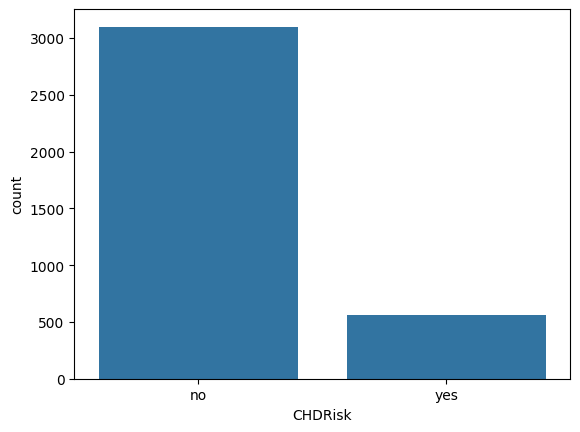

In [ ]:
#verificando se o dataset está balanceado (não está)
sns.countplot(x = heart_data["CHDRisk"])

Dividimos as variavéis em categorias:
##Categorização de Idade
- [32, 40)
- [40, 48)
- [48, 55)
- [55, 70]


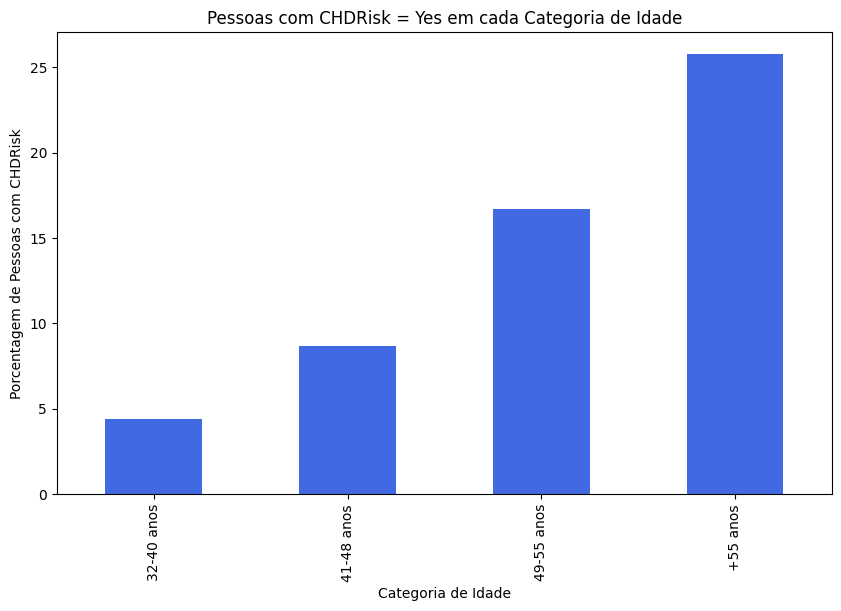

In [ ]:
# Cria uma nova coluna 'categoria_idade' com base nas faixas de idade
heart_data['categoria_idade'] = pd.cut(heart_data['age'],
                                      bins=[32, 40, 48, 55, float('inf')],
                                      labels=['32-40 anos', '41-48 anos', '49-55 anos', '+55 anos'],
                                      right=False)

# Calcula a porcentagem de pessoas com CHDRisk = 'yes' em cada categoria de idade
def calcular_porcentagem(group):
  return (group['CHDRisk'].value_counts(normalize=True) * 100)['yes']

categoria_idade_percentage = heart_data.groupby('categoria_idade').apply(calcular_porcentagem)

# Ordena as categorias de idade
categoria_idade_percentage = categoria_idade_percentage.sort_index()

# Cria o gráfico de barras com as porcentagens
plt.figure(figsize=(10, 6))
categoria_idade_percentage.plot(kind='bar', color='royalblue')
plt.title('Pessoas com CHDRisk = Yes em cada Categoria de Idade')
plt.xlabel('Categoria de Idade')
plt.ylabel('Porcentagem de Pessoas com CHDRisk')
plt.show()

## Categorização de Cigarros por dia
- [1, 6)
- [6, 15)
- [15, 30)
- [30, 70] no caso até o valor máximo no dataset

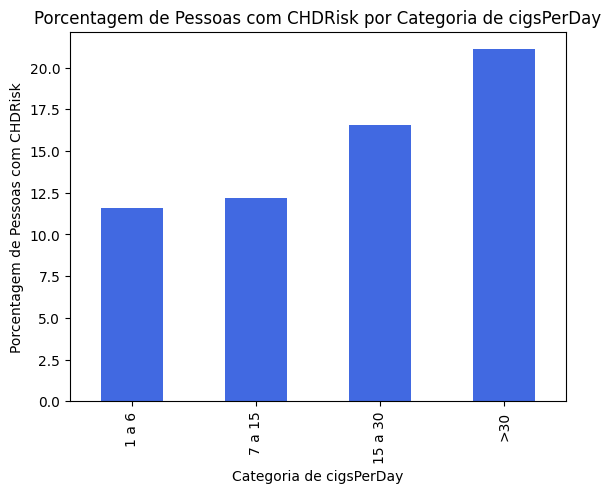

In [ ]:
# Cria uma nova coluna 'categoria_cigs' com base nas faixas de 'cigsPerDay' (excluindo 0)
heart_data['categoria_cigs'] = pd.cut(heart_data['cigsPerDay'],
                                     bins=[1, 6, 15, 30, float('inf')],
                                     labels=['1 a 6', '7 a 15', '15 a 30', '>30'],
                                     right=False)

# Calcula o total de pessoas para cada categoria de 'cigsPerDay'
total_pessoas_por_categoria = heart_data.groupby('categoria_cigs').size()

# Calcula o número de pessoas com CHDRisk para cada categoria de 'cigsPerDay'
pessoas_com_chdrisk_por_categoria = heart_data[heart_data['CHDRisk'] == 'yes'].groupby('categoria_cigs').size()

# Calcula a porcentagem de pessoas com CHDRisk para cada categoria de 'cigsPerDay'
porcentagem_chdrisk_por_categoria = (pessoas_com_chdrisk_por_categoria / total_pessoas_por_categoria) * 100

# Cria o gráfico de barras
porcentagem_chdrisk_por_categoria.plot(kind='bar', color='royalblue')
plt.title('Porcentagem de Pessoas com CHDRisk por Categoria de cigsPerDay')
plt.xlabel('Categoria de cigsPerDay')
plt.ylabel('Porcentagem de Pessoas com CHDRisk')
plt.show()

## Distribuição por hipertensão

<ipython-input-17-64758fc670d6>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=heart_data[heart_data['CHDRisk'] == 'yes'], x='prevalentHyp', palette=['blue', 'red'])


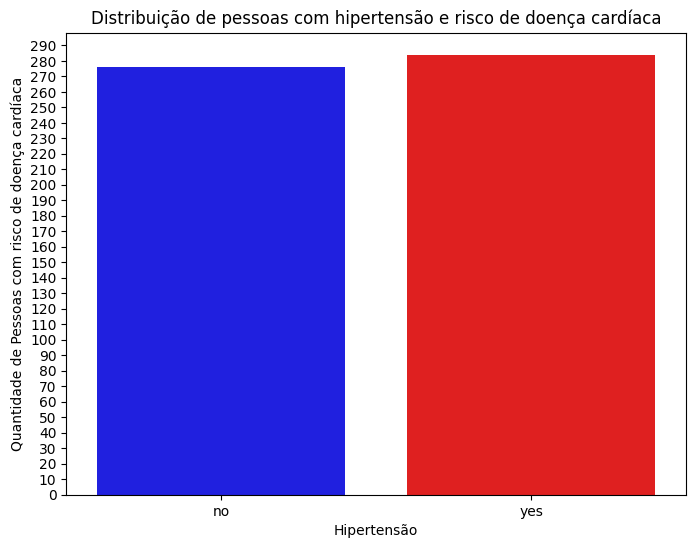

In [ ]:
# Set up the figure
plt.figure(figsize=(8, 6))

# Create the count plot
sns.countplot(data=heart_data[heart_data['CHDRisk'] == 'yes'], x='prevalentHyp', palette=['blue', 'red'])

# Set the labels and title
plt.xlabel('Hipertensão')
plt.ylabel('Quantidade de Pessoas com risco de doença cardíaca')
plt.title('Distribuição de pessoas com hipertensão e risco de doença cardíaca')

# Adjust the vertical scale to count in increments of 10
max_count = heart_data[heart_data['CHDRisk'] == 'yes']['prevalentHyp'].value_counts().max()
plt.yticks(np.arange(0, max_count + 10, 10))

# Change x-axis labels from 1 and 0 to yes and no
plt.xticks(ticks=[0, 1], labels=['no', 'yes'])

# Display the plot
plt.show()

## Distribuição por sexo

<ipython-input-18-dba760fe8886>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=heart_data[heart_data['CHDRisk'] == 'yes'], x='sex', palette=['pink', 'blue'])


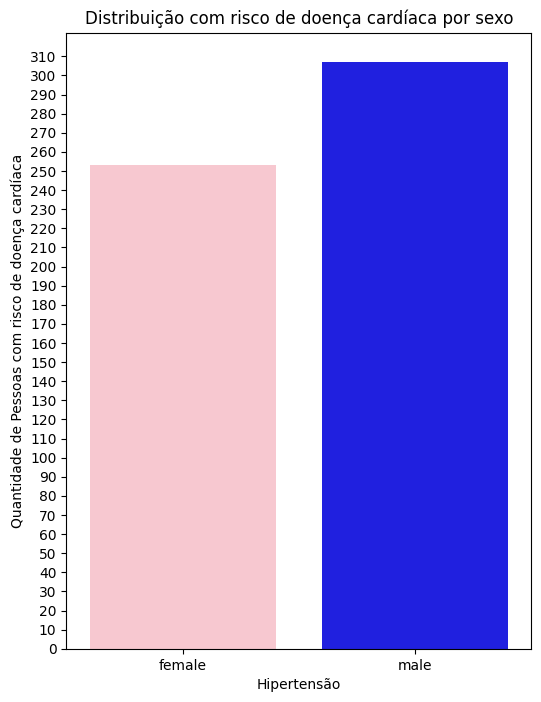

In [ ]:
# Set up the figure
plt.figure(figsize=(6, 8))

# Create the count plot
sns.countplot(data=heart_data[heart_data['CHDRisk'] == 'yes'], x='sex', palette=['pink', 'blue'])

# Set the labels and title
plt.xlabel('Hipertensão')
plt.ylabel('Quantidade de Pessoas com risco de doença cardíaca')
plt.title('Distribuição com risco de doença cardíaca por sexo')

# Adjust the vertical scale to count in increments of 10
max_count = heart_data[heart_data['CHDRisk'] == 'yes']['sex'].value_counts().max()
plt.yticks(np.arange(0, max_count + 10, 10))

# Change x-axis labels from 1 and 0 to yes and no
plt.xticks(ticks=[0, 1], labels=['female', 'male'])

# Display the plot
plt.show()

##Categorização do colesterol
- [113, 200)
- [200, 240)
- [240, 600] o val. máximo no dataset

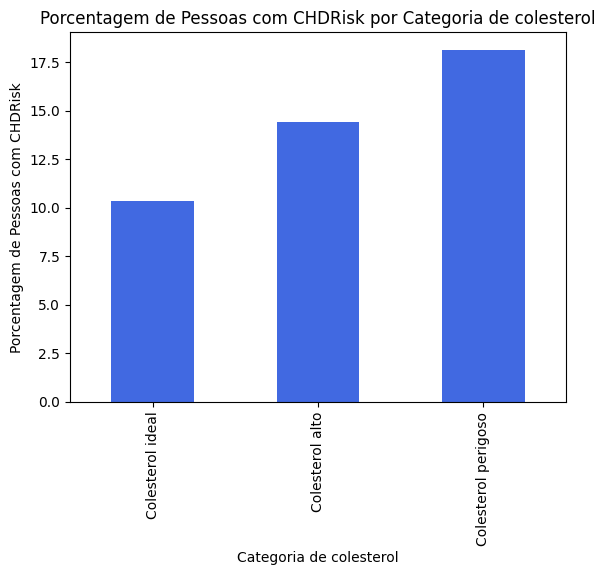

In [ ]:
# Cria uma nova coluna 'categoria_chol' com base nas faixas de 'totChol' (excluindo 0)
heart_data['categoria_chol'] = pd.cut(heart_data['totChol'],
                                     bins=[113, 200, 240, float('inf')],
                                     labels=['Colesterol ideal', 'Colesterol alto', 'Colesterol perigoso'],
                                     right=False)

# Calcula o total de pessoas para cada categoria de 'totChol'
total_pessoas_por_categoria_chol = heart_data.groupby('categoria_chol').size()

# Calcula o número de pessoas com CHDRisk para cada categoria de 'totChol'
pessoas_com_chdrisk_por_categoria_chol = heart_data[heart_data['CHDRisk'] == 'yes'].groupby('categoria_chol').size()

# Calcula a porcentagem de pessoas com CHDRisk para cada categoria de 'totChol'
porcentagem_chdrisk_por_categoria_chol = (pessoas_com_chdrisk_por_categoria_chol / total_pessoas_por_categoria_chol) * 100

# Cria o gráfico de barras
porcentagem_chdrisk_por_categoria_chol.plot(kind='bar', color='royalblue')
plt.title('Porcentagem de Pessoas com CHDRisk por Categoria de colesterol')
plt.xlabel('Categoria de colesterol')
plt.ylabel('Porcentagem de Pessoas com CHDRisk')
plt.show()

##Categorização do IMC
- [15.5, 18.5)
- [18.5, 25)
- [30, 56.8]

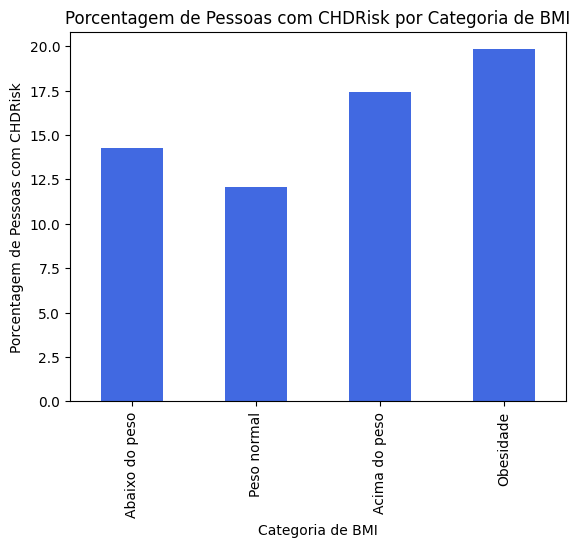

In [ ]:
# Cria uma nova coluna 'categoria_BMI' com base nas faixas de 'BMI' (excluindo 0)
heart_data['categoria_BMI'] = pd.cut(heart_data['BMI'],
                                     bins=[15.5, 18.5, 25, 30, float('inf')],
                                     labels=['Abaixo do peso', 'Peso normal', 'Acima do peso', 'Obesidade'],
                                     right=False)

# Calcula o total de pessoas para cada categoria de 'BMI'
total_pessoas_por_categoria_bmi = heart_data.groupby('categoria_BMI').size()

# Calcula o número de pessoas com CHDRisk para cada categoria de 'BMI'
pessoas_com_chdrisk_por_categoria_bmi = heart_data[heart_data['CHDRisk'] == 'yes'].groupby('categoria_BMI').size()

# Calcula a porcentagem de pessoas com CHDRisk para cada categoria de 'BMI'
porcentagem_chdrisk_por_categoria_bmi = (pessoas_com_chdrisk_por_categoria_bmi / total_pessoas_por_categoria_bmi) * 100

# Cria o gráfico de barras
porcentagem_chdrisk_por_categoria_bmi.plot(kind='bar', color='royalblue')
plt.title('Porcentagem de Pessoas com CHDRisk por Categoria de BMI')
plt.xlabel('Categoria de BMI')
plt.ylabel('Porcentagem de Pessoas com CHDRisk')
plt.show()

##Categorização da Glicose
- [40, 70)
- [70, 101)
- [101, 126)
- [126, 300]

Text(0, 0.5, 'Porcentagem de Pessoas com CHDRisk')

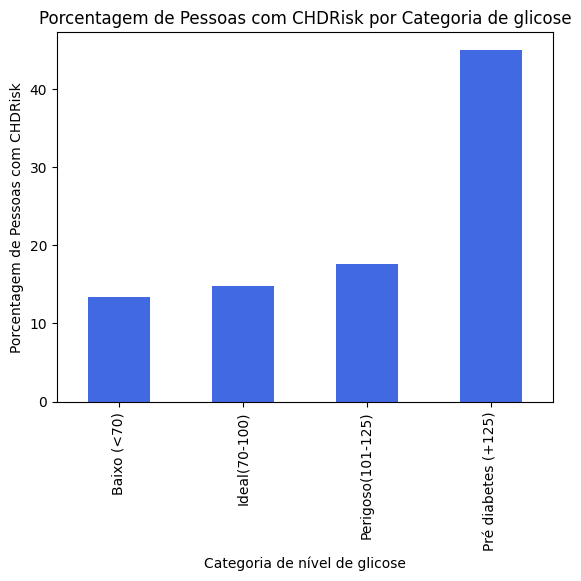

In [ ]:
# Cria uma nova coluna 'categoria_gluc' com base nas faixas de 'glicose' (excluindo 0)
heart_data['categoria_gluc'] = pd.cut(heart_data['glucose'],
                                     bins=[40 ,70, 101, 126, float('inf')],
                                     labels=['Baixo (<70)', 'Ideal(70-100)', 'Perigoso(101-125)', 'Pré diabetes (+125)'],
                                     right=False)

# Calcula o total de pessoas para cada categoria de 'totChol'
total_pessoas_por_categoria_gluc = heart_data.groupby('categoria_gluc').size()

# Calcula o número de pessoas com CHDRisk para cada categoria de 'totChol'
pessoas_com_chdrisk_por_categoria_gluc = heart_data[heart_data['CHDRisk'] == 'yes'].groupby('categoria_gluc').size()

# Calcula a porcentagem de pessoas com CHDRisk para cada categoria de 'totChol'
porcentagem_chdrisk_por_categoria_gluc= (pessoas_com_chdrisk_por_categoria_gluc / total_pessoas_por_categoria_gluc) * 100

# Cria o gráfico de barras
porcentagem_chdrisk_por_categoria_gluc.plot(kind='bar', color='royalblue')
plt.title('Porcentagem de Pessoas com CHDRisk por Categoria de glicose')
plt.xlabel('Categoria de nível de glicose')
plt.ylabel('Porcentagem de Pessoas com CHDRisk')

In [ ]:
# separar variáveis entre X e y
X_columns = ['age', 'cigsPerDay', 'totChol', 'BMI','glucose']
X = heart_data[X_columns] # variáveis independentes
y = heart_data['CHDRisk'] # variável alvo
heart_data

,sex,age,education,smokingStatus,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,...,diaBP,BMI,heartRate,glucose,CHDRisk,categoria_idade,categoria_cigs,categoria_chol,categoria_BMI,categoria_gluc
0,male,39,4,no,0,0,0,0,no,195,...,70.0,26.97,80,77,no,32-40 anos,NaN,Colesterol ideal,Acima do peso,Ideal(70-100)
1,female,46,2,no,0,0,0,0,no,250,...,81.0,28.73,95,76,no,41-48 anos,NaN,Colesterol perigoso,Acima do peso,Ideal(70-100)
2,male,48,1,yes,20,0,0,0,no,245,...,80.0,25.34,75,70,no,49-55 anos,15 a 30,Colesterol perigoso,Acima do peso,Ideal(70-100)
3,female,61,3,yes,30,0,0,1,no,225,...,95.0,28.58,65,103,yes,+55 anos,>30,Colesterol alto,Acima do peso,Perigoso(101-125)
4,female,46,3,yes,23,0,0,0,no,285,...,84.0,23.10,85,85,no,41-48 anos,15 a 30,Colesterol perigoso,Peso normal,Ideal(70-100)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3654,male,51,3,no,43,0,0,0,no,207,...,80.0,19.71,65,68,no,49-55 anos,>30,Colesterol alto,Peso normal,Baixo (<70)
3655,female,52,2,no,0,0,0,0,no,269,...,83.0,21.47,80,107,no,49-55 anos,NaN,Colesterol perigoso,Peso normal,Perigoso(101-125)
3656,female,47,4,yes,20,0,0,0,no,294,...,68.0,24.18,62,66,yes,41-48 anos,15 a 30,Colesterol perigoso,Peso normal,Baixo (<70)
3657,female,58,1,no,0,0,0,0,no,233,...,84.0,26.05,67,76,yes,+55 anos,NaN,Colesterol alto,Acima do peso,Ideal(70-100)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, shuffle=True, test_size=0.2, random_state=0)

# criando uma instância do RandomUnderSampling
rus = RandomUnderSampler(random_state=42, sampling_strategy = 'majority')
X_resampled, y_resampled = rus.fit_resample(X_train, y_train) #balanceando os dados de treino

In [ ]:
#Treinando o modelo
clf = CategoricalNB()
clf.fit(X_resampled, y_resampled)

#Avaliando o modelo
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.6270491803278688

              precision    recall  f1-score   support

          no       0.91      0.62      0.74       620
         yes       0.24      0.64      0.35       112

    accuracy                           0.63       732
   macro avg       0.57      0.63      0.54       732
weighted avg       0.80      0.63      0.68       732



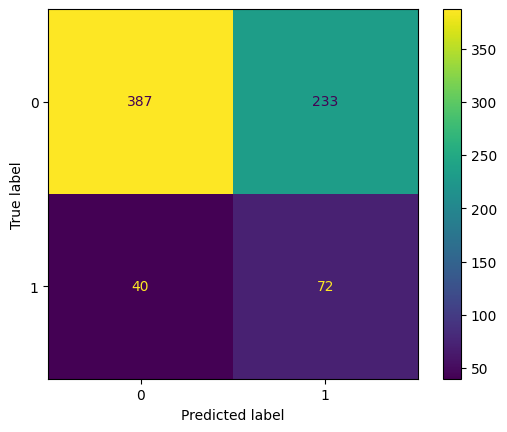

In [ ]:
# Convert y_test and y_pred to a consistent data type (e.g., integers)
# Assuming 'yes' maps to 1 and 'no' maps to 0
y_test_int = y_test.map({'yes': 1, 'no': 0})
y_pred_int = pd.Series(y_pred).map({'yes': 1, 'no': 0})  # Convert y_pred to Series first

# Now use the integer versions in the confusion matrix
labels = [0, 1]  # Update labels to match the integer classes
cm = confusion_matrix(y_test_int, y_pred_int, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot();